In [1]:
import numpy as np
import matplotlib.pyplot as plt

def true_function(x):
    """
    真实函数（模型并不知道）
    """
    x = np.asarray(x, dtype=float)
    return 1.2 * np.sin(x) + 0.3 * x - 2.0

In [2]:
import numpy as np

print(true_function(1.0))              # 输入一个数字
print(true_function([0, 1, 2]))        # 输入一个列表
print(true_function(np.array([3, 4]))) # 输入数组

-0.6902348182305242
[-2.         -0.69023482 -0.30884309]
[-0.93065599 -1.70816299]


In [3]:
# =========================================================
# 2. RBF kernel
# =========================================================
def rbf_kernel(X1, X2, ell=1.0, sigma=1.0):
    """
    使用显式双重循环实现RBF核
    RBF kernel / Gaussian kernel
    k(x, x') = sigma^2 * exp(-(x-x')^2 / (2*ell^2))
    """
    # 转换为列表或一维数组
    X1 = np.asarray(X1).flatten()
    X2 = np.asarray(X2).flatten()
    
    n = len(X1)
    m = len(X2)
    
    # 初始化核矩阵
    K = np.zeros((n, m))
    
    # 双重循环计算每个点对
    for i in range(n):
        for j in range(m):
            # 计算两个点之间的差
            diff = X1[i] - X2[j]
            # 计算RBF核
            K[i, j] = sigma**2 * np.exp(-0.5 * diff**2 / ell**2)
            
    return K

**两个点之间的相似度** 
>解释：1.0 和 1.2 很近, 所以 kernel 值会比较大，接近 1

In [4]:
K = rbf_kernel([1.0], [1.2], ell=1.0, sigma=1.0)
print(K)

[[0.98019867]]


**多个点的核矩阵** 
- 对角线：点和自己比较，相似度最大
- 离得近的点：值较大
- 离得远的点：值较小

In [5]:
X = [1.0, 2.0, 3.0]
K = rbf_kernel(X, X, ell=1.0, sigma=1.0)
print(K)

[[1.         0.60653066 0.13533528]
 [0.60653066 1.         0.60653066]
 [0.13533528 0.60653066 1.        ]]


In [11]:
X1 = [1, 2]
X2 = [1, 3]

K = rbf_kernel(X1, X2, ell=1.0, sigma=1.0)
"""
[[k(1,1), k(1,3)],
 [k(2,1), k(2,3)]]
"""
print(K)

[[1.         0.13533528]
 [0.60653066 0.60653066]]


### Gaussian Process Regression

Next, we use formulas to derive the process shown in the figure above. Represent the **prior** of the Gaussian process as $f(\boldsymbol{x}) \sim \mathcal{N}(\mu_f, K_{ff})$. If we now observe some data $(\boldsymbol{x}^*, \boldsymbol{y}^*)$, and assume that $\boldsymbol{y}^*$ and $f(\boldsymbol{x})$ follow a joint Gaussian distribution:

$$\begin{bmatrix} f(\boldsymbol{x}) \\ \boldsymbol{y}^* \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mu_f \\ \mu_y \end{bmatrix}, \begin{bmatrix} K_{ff} & K_{fy} \\ K_{fy}^T & K_{yy} \end{bmatrix} \right)$$

Where:
$$K_{ff} = \kappa(\boldsymbol{x}, \boldsymbol{x})$$
$$K_{fy} = \kappa(\boldsymbol{x}, \boldsymbol{x}^*)$$
$$K_{yy} = \kappa(\boldsymbol{x}^*, \boldsymbol{x}^*)$$

Then we have:

$$f \sim \mathcal{N}(K_{fy}^T K_{ff}^{-1} \boldsymbol{y} + \mu_f, K_{yy} - K_{fy}^T K_{ff}^{-1} K_{fy})$$

The above equation indicates that given the data $(\boldsymbol{x}^*, \boldsymbol{y}^*)$, the distribution of the function $f$ is still a Gaussian process. 

In [12]:
def gp_posterior_predict(X_train, y_train, X_test,
                         ell=1.0, sigma=1.0, sigma_e=0.3, jitter=1e-8):
    """
    Gaussian Process posterior prediction

    输入:
        X_train : 训练输入
        y_train : 训练输出
        X_test  : 测试输入
        ell     : kernel length scale
        sigma   : kernel output scale
        sigma_e : 观测噪声标准差
        jitter  : 数值稳定项

    输出:
        mu_s   : 后验均值
        cov_s  : 后验协方差矩阵
        std_s  : 后验标准差
    """
    X_train = np.asarray(X_train, dtype=float).ravel()
    y_train = np.asarray(y_train, dtype=float).ravel()
    X_test = np.asarray(X_test, dtype=float).ravel()

    K = rbf_kernel(X_train, X_train, ell=ell, sigma=sigma)
    K_s = rbf_kernel(X_train, X_test, ell=ell, sigma=sigma)
    K_ss = rbf_kernel(X_test, X_test, ell=ell, sigma=sigma)

    C = K + (sigma_e**2 + jitter) * np.eye(len(X_train))

    C = K + (sigma_e**2 + jitter) * np.eye(len(X_train))
    C_inv = np.linalg.inv(C)

    mu_s = K_s.T @ C_inv @ y_train
    cov_s = K_ss - K_s.T @ C_inv @ K_s
    std_s = np.sqrt(np.maximum(np.diag(cov_s), 0))

    return mu_s, cov_s, std_s

In [13]:
X_train = [1.0, 3.0, 5.0] # 已知 3 个训练点
y_train = [2.0, 0.0, 1.0] # 已知 3 个训练点的值
X_test = [2.0, 4.0] # # 想知道 x=2 和 x=4 这两个位置会是什么值

mu, cov, std = gp_posterior_predict(
    X_train, y_train, X_test,
    ell=1.0, sigma=1.0, sigma_e=0.1
)

print("预测均值 =", mu) # 最可能的预测值
print("预测标准差 =", std) # 这个预测有多不确定

预测均值 = [0.99567816 0.4059559 ]
预测标准差 = [0.59488102 0.59488102]


### Log Marginal Likelihood

To optimize hyperparameters $\theta$, we maximize the log marginal likelihood:

$$\log p(y | X, \theta) = -\frac{1}{2}\boldsymbol{y}^T C^{-1} \boldsymbol{y} - \frac{1}{2} \log |C| - \frac{n}{2} \log (2\pi)$$

It consists of three components:
1.  **Term 1 ($-\frac{1}{2}\boldsymbol{y}^T C^{-1} \boldsymbol{y}$):** Measures how well the model fits the data (Data Fit).
2.  **Term 2 ($-\frac{1}{2} \log |C|$):** Complexity penalty to prevent over-fitting (Complexity Penalty).
3.  **Term 3 ($-\frac{n}{2} \log (2\pi)$):** A normalization constant.

In [14]:
# =========================================================
# 4. log marginal likelihood
# =========================================================
def log_marginal_likelihood(X, y, ell=1.0, sigma=1.0, sigma_e=0.3, jitter=1e-8):
    """
    log p(y | X, ell, sigma, sigma_e)
    """
    X = np.asarray(X)
    y = np.asarray(y)

    K = rbf_kernel(X, X, ell=ell, sigma=sigma)
    C = K + (sigma_e**2 + jitter) * np.eye(len(X))

    sign, logdet = np.linalg.slogdet(C)
    C_inv = np.linalg.inv(C)

    term1 = -0.5 * y.T @ C_inv @ y
    term2 = -0.5 * logdet
    term3 = -0.5 * len(X) * np.log(2 * np.pi)

    return term1 + term2 + term3

In [15]:
X = [1.0, 2.0, 3.0]
y = [1.2, 1.9, 3.1]

# 哪个 ell 更适合当前数据？
# 哪个噪声水平更合理？
# 哪个模型更“解释得通”？

lml1 = log_marginal_likelihood(X, y, ell=0.5, sigma=1.0, sigma_e=0.1)
lml2 = log_marginal_likelihood(X, y, ell=2.0, sigma=1.0, sigma_e=0.1)

# log marginal likelihood 越大越好
print("ell=0.5 时的 LML =", lml1)
print("ell=2.0 时的 LML =", lml2)

ell=0.5 时的 LML = -9.122674020364055
ell=2.0 时的 LML = -8.259862146293727


In [16]:
def generate_noisy_observations(x, noise_std=0.35, seed=None):
    """
    根据真实函数生成带噪声的观测数据

    输入:
        x         : 输入点
        noise_std : 噪声标准差
        seed      : 随机种子

    输出:
        y_true    : 真实函数值
        y_obs     : 带噪声观测值
    """
    x = np.asarray(x, dtype=float)

    if seed is not None:
        np.random.seed(seed)

    y_true = true_function(x)
    y_obs = y_true + np.random.normal(0, noise_std, size=len(x))

    return y_true, y_obs

In [17]:
# 我们测量到的数据会有误差, 观测值 = 真实值 + 噪声， 为不确定性估计提供基础, 更好地评估模型性能

x_train = np.linspace(0, 10, 5)
y_true, y_obs = generate_noisy_observations(x_train, noise_std=0.2, seed=0)

print("真实值 =", y_true)
print("观测值 =", y_obs)

真实值 = [-2.         -0.53183343 -1.65070913  1.37559997  0.34717467]
观测值 = [-1.64718953 -0.45180199 -1.45496153  1.82377861  0.72068626]


### Standard Normal Distribution:
$$Z \sim \mathcal{N}(0, 1)$$

There is a classic conclusion:
$$P(-1.96 \leq Z \leq 1.96) \approx 0.95$$

---

### Generalization to Any Normal Distribution
If:
$$X \sim \mathcal{N}(\mu, \sigma^2)$$

Then:
$$P(\mu - 1.96\sigma \leq X \leq \mu + 1.96\sigma) \approx 95\%$$

In [28]:
import numpy as np

np.random.seed(0)

# 生成100000个标准正态分布数据
samples = np.random.normal(0, 1, 100000)

# 计算在 [-1.96, 1.96] 内的比例
count = np.sum((samples >= -1.96) & (samples <= 1.96))
ratio = count / len(samples)

print("比例 =", ratio)

比例 = 0.95029


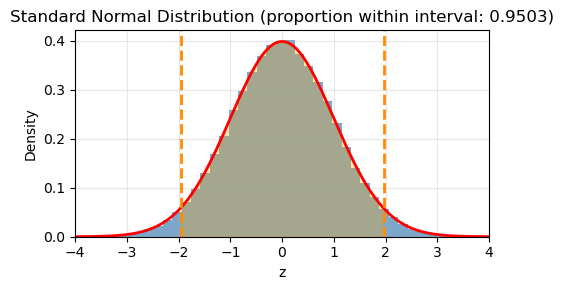

In [29]:
# 快速绘图
plt.figure(figsize=(5, 3))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='steelblue')

# 添加理论曲线
x = np.linspace(-4, 4, 200)
plt.plot(x, 1/np.sqrt(2*np.pi)*np.exp(-x**2/2), 'r-', lw=2)

# 标记区间
plt.axvline(-1.96, color='darkorange', linestyle='--', lw=2)
plt.axvline(1.96, color='darkorange', linestyle='--', lw=2)
plt.fill_between(x, 1/np.sqrt(2*np.pi)*np.exp(-x**2/2), 
                 where=(x >= -1.96) & (x <= 1.96),
                 color='orange', alpha=0.3)

plt.title(f'Standard Normal Distribution (proportion within interval: {ratio:.4f})')
plt.xlabel('z')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.tight_layout()
plt.show()

In [31]:
import numpy as np

np.random.seed(0)

mu = 5
sigma = 2

samples = np.random.normal(mu, sigma, 100000)

lower = mu - 1.96 * sigma
upper = mu + 1.96 * sigma

ratio = np.mean((samples >= lower) & (samples <= upper))

print("95%区间 =", lower, upper)
print("比例 =", ratio)

95%区间 = 1.08 8.92
比例 = 0.95029


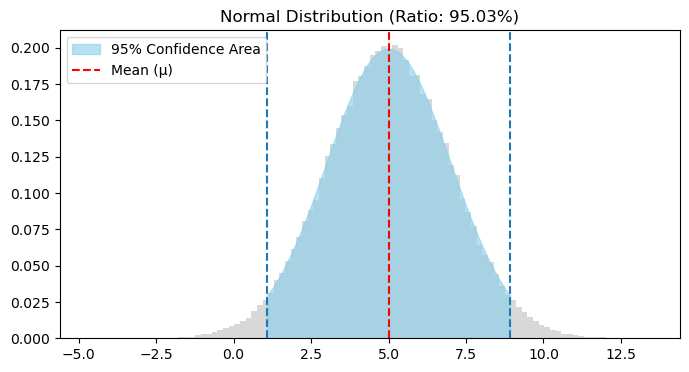

In [33]:
plt.figure(figsize=(8, 4))
count, bins, _ = plt.hist(samples, bins=100, density=True, alpha=0.3, color='gray')

# 填充 95% 区域
x = np.linspace(lower, upper, 100)
y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
plt.fill_between(x, y, color='skyblue', alpha=0.6, label='95% Confidence Area')

plt.axvline(lower, linestyle="--")
plt.axvline(upper, linestyle="--")

plt.axvline(mu, color='red', linestyle='--', label='Mean (μ)')
plt.title(f"Normal Distribution (Ratio: {ratio:.2%})")
plt.legend()
plt.show()

**，GP可以 10 个训练点 → 预测 300 个测试点**

log marginal likelihood = -11.27030386763009


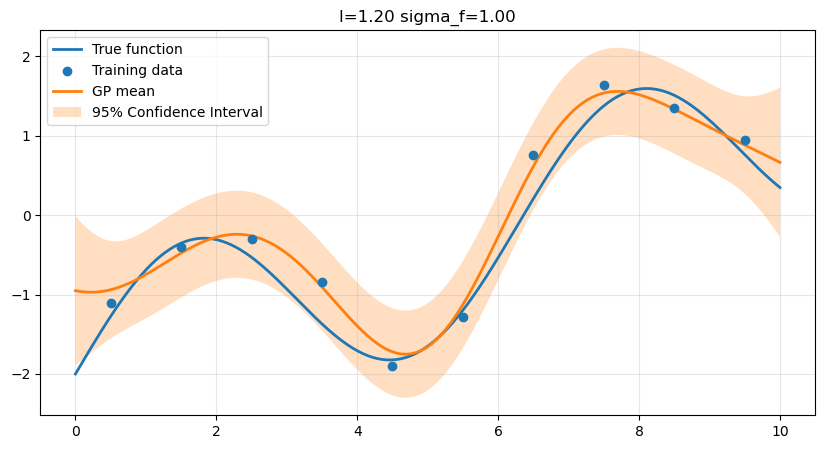

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# 10个训练点
x_train = np.linspace(0.5, 9.5, 10) # 已知观测到10个点的位置

# 已知观测到10个点的真实值，带噪声观测值
y_true_train, y_train = generate_noisy_observations(x_train, noise_std=0.35, seed=42) 

# 测试点
x_test = np.linspace(0, 10, 300)
y_true_test = true_function(x_test)

ell=1.2
sigma=1.0
# GP预测
mu, cov, std = gp_posterior_predict(
    x_train, y_train, x_test,
    ell=ell, sigma=sigma, sigma_e=0.35
)

# LML
lml = log_marginal_likelihood(x_train, y_train, ell=ell, sigma=sigma, sigma_e=0.35)
print("log marginal likelihood =", lml)

# 画图
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_true_test, label="True function", linewidth=2)
plt.title("l=%.2f sigma_f=%.2f" % (ell, sigma))
plt.scatter(x_train, y_train, label="Training data", zorder=3)
plt.plot(x_test, mu, label="GP mean", linewidth=2)
plt.fill_between(x_test, mu - 1.96*std, mu + 1.96*std, alpha=0.25, label="95% Confidence Interval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

log marginal likelihood = -14.903464718381098


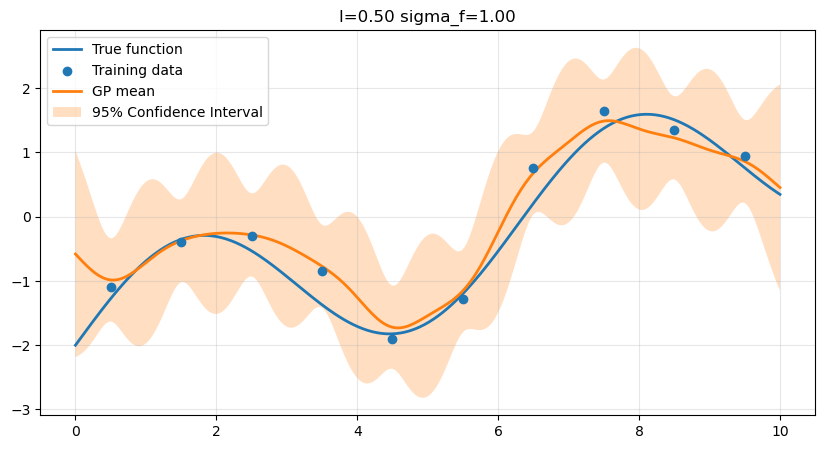

In [40]:
ell=0.5
sigma=1.0
# GP预测
mu, cov, std = gp_posterior_predict(
    x_train, y_train, x_test,
    ell=ell, sigma=sigma, sigma_e=0.35
)

# LML
lml = log_marginal_likelihood(x_train, y_train, ell=ell, sigma=sigma, sigma_e=0.35)
print("log marginal likelihood =", lml)

# 画图
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_true_test, label="True function", linewidth=2)
plt.title("l=%.2f sigma_f=%.2f" % (ell, sigma))
plt.scatter(x_train, y_train, label="Training data", zorder=3)
plt.plot(x_test, mu, label="GP mean", linewidth=2)
plt.fill_between(x_test, mu - 1.96*std, mu + 1.96*std, alpha=0.25, label="95% Confidence Interval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

log marginal likelihood = -24.98741473546758


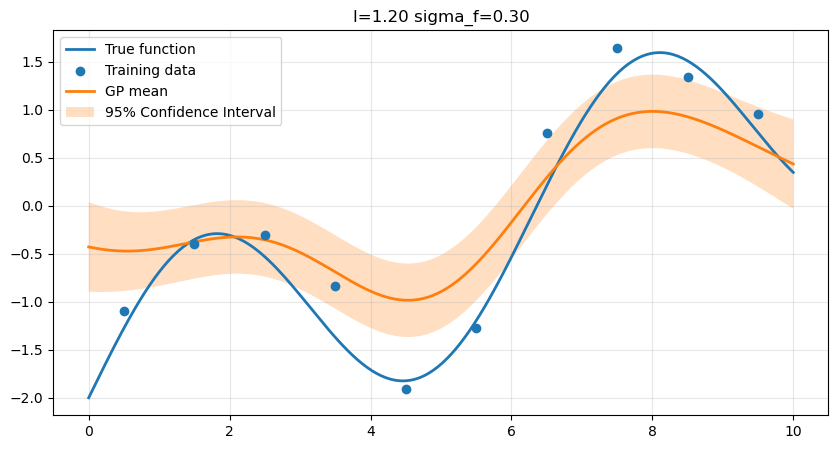

In [42]:
ell=1.2
sigma=0.3
# GP预测
mu, cov, std = gp_posterior_predict(
    x_train, y_train, x_test,
    ell=ell, sigma=sigma, sigma_e=0.35
)

# LML
lml = log_marginal_likelihood(x_train, y_train, ell=ell, sigma=sigma, sigma_e=0.35)
print("log marginal likelihood =", lml)

# 画图
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_true_test, label="True function", linewidth=2)
plt.title("l=%.2f sigma_f=%.2f" % (ell, sigma))
plt.scatter(x_train, y_train, label="Training data", zorder=3)
plt.plot(x_test, mu, label="GP mean", linewidth=2)
plt.fill_between(x_test, mu - 1.96*std, mu + 1.96*std, alpha=0.25, label="95% Confidence Interval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Hyperparameter Optimization
How do we choose the optimal kernel parameters $\sigma$ and $l$? We maximize the **Marginal Log-likelihood**:
$$\log p(\boldsymbol{y} | \sigma, l) = \log \mathcal{N}(\mathbf{0}, K_{yy}(\sigma, l)) = -\frac{1}{2}\boldsymbol{y}^T K_{yy}^{-1} \boldsymbol{y} - \frac{1}{2} \log |K_{yy}| - \frac{N}{2} \log (2\pi)$$

In implementation, we let the program automatically find the best hyperparameters $\theta = (l, \sigma, \sigma_e)$ by:
$$\theta^* = \arg \max_{\theta} \log p(y | X, \theta)$$
- `ell`: Length scale
- `sigma`: Signal standard deviation
- `sigma_e`: Noise standard deviation

In [44]:
def optimize_hyperparameters_grid(X, y,
                                  ell_candidates,
                                  sigma_candidates,
                                  sigma_e_candidates):
    """
    用 grid search 最大化 log marginal likelihood

    返回:
        best_params : dict
        best_lml    : 最优 log marginal likelihood
        history     : 所有尝试过的结果
    """
    best_lml = -np.inf
    best_params = None
    history = []

    for ell in ell_candidates:
        for sigma in sigma_candidates:
            for sigma_e in sigma_e_candidates:
                lml = log_marginal_likelihood(
                    X, y,
                    ell=ell,
                    sigma=sigma,
                    sigma_e=sigma_e
                )

                history.append((ell, sigma, sigma_e, lml))

                if lml > best_lml:
                    best_lml = lml
                    best_params = {
                        "ell": ell,
                        "sigma": sigma,
                        "sigma_e": sigma_e
                    }

    return best_params, best_lml, history

In [45]:
ell_candidates = np.linspace(0.3, 3.0, 15)
sigma_candidates = np.linspace(0.5, 2.0, 10)
sigma_e_candidates = np.linspace(0.05, 0.8, 12)

best_params, best_lml, history = optimize_hyperparameters_grid(
    x_train, y_train,
    ell_candidates,
    sigma_candidates,
    sigma_e_candidates
)

print("最优超参数 =", best_params)
print("最优 LML =", best_lml)

最优超参数 = {'ell': 1.4571428571428573, 'sigma': 1.3333333333333333, 'sigma_e': 0.05}
最优 LML = -8.997157955995268


In [46]:
mu2, cov2, std2 = gp_posterior_predict(
    x_train, y_train, x_test,
    ell=best_params["ell"],
    sigma=best_params["sigma"],
    sigma_e=best_params["sigma_e"]
)

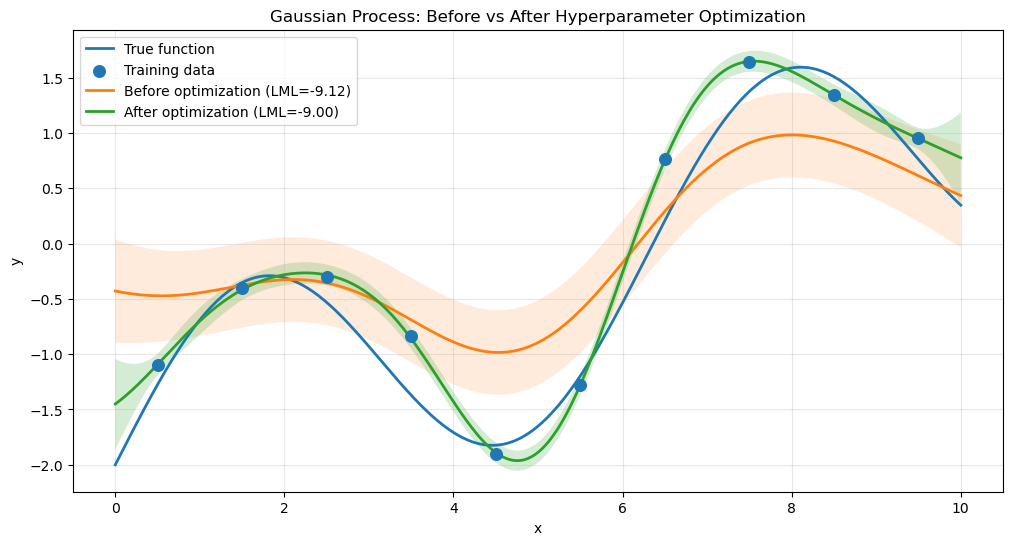

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(x_test, y_true_test, linewidth=2, label="True function")
plt.scatter(x_train, y_train, s=70, zorder=3, label="Training data")

plt.plot(x_test, mu, linewidth=2, label=f"Before optimization (LML={lml1:.2f})")
plt.fill_between(
    x_test,
    mu - 1.96 * std,
    mu + 1.96 * std,
    alpha=0.15
)

plt.plot(x_test, mu2, linewidth=2, label=f"After optimization (LML={best_lml:.2f})")
plt.fill_between(
    x_test,
    mu2 - 1.96 * std2,
    mu2 + 1.96 * std2,
    alpha=0.20
)

plt.title("Gaussian Process: Before vs After Hyperparameter Optimization")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()